# v5 - the sign of W: does Parcels need `-W` or `+W`?

`v4_poissonB_vs_FixW.ipynb` runs each fieldset twice, once with the stock `AdvectionRK4_3D`
(`particle_ddepth += w*dt`, "posW") and once with a hand-written `AdvectionRK4_3D_negW`
(`particle_ddepth -= w*dt`, "negW"). This notebook was opened to test the claim that the
negation is wrong and that `+W` is the correct choice.

## Verdict

**The negation in v4 is physically correct. `+W` on that fieldset is wrong.** Five independent
lines of evidence agree, including one that uses no metadata at all (Test 2) and one that uses
no Parcels internals at all (Test 5).

The stored `vovecrtz` is **positive upward**; Parcels' depth axis is **positive downward**; and
`FieldSet.from_netcdf` - which v4 uses - applies **no** sign correction. So
`d(depth)/dt = -W` is required, and v4's `negW` kernel supplies it.

## But the instinct behind the claim is right, and points at a real defect

The *kernel* should indeed be the stock `AdvectionRK4_3D`, i.e. `+W`. The way to get there is
**not** to drop the negation - it is to move the negation out of the kernel and onto the field,
by building the fieldset with `FieldSet.from_nemo`, which does exactly that itself
(`parcels/fieldset.py:657`, `fieldset.W.set_scaling_factor(-1.0)`).

So v4 reaches the right physics by the wrong route: it hand-rolls a library behaviour. Three
things follow, all of them bad, and Test 4 and Test 6 measure them:

1. Every `fieldset.W[...]` sample outside the advection kernel - present or future diagnostics -
   still sees the **un-negated**, positive-upward W. A W-sign bug there would be invisible.
2. If anyone later switches v4's `build_fieldset` to `from_nemo` and keeps `negW`, the flip is
   applied **twice** and the sign error becomes real.
3. The four-way `posW` / `negW` sweep presents a settled question as an open one, and half the
   compute is spent on a configuration that is known-wrong before it is run.

Test 6 shows `from_nemo` + stock `AdvectionRK4_3D` reproduces v4's `negW` trajectories to the
last bit, so the fix costs nothing.

In [1]:
import os, math, textwrap
import numpy as np
import xarray as xr

YEAR, MONTH  = 1993, 1
ZGR, HGR     = "Zgr_cmesh2.nc", "Hgr_cmesh.nc"
U_RAW        = f"U_{YEAR}-{MONTH:02d}.nc"        # GLORYS as delivered
V_RAW        = f"V_{YEAR}-{MONTH:02d}.nc"
W_RAW        = f"W_{YEAR}-{MONTH:02d}.nc"
W_POISSON    = f"W_{YEAR}-{MONTH:02d}b.nc"       # v4's "poisson_b" W
W_FIXW       = f"W_{YEAR}-{MONTH:02d}fc2.nc"     # v4's "fix_w"    W
TSTEP        = 1                                  # which daily record to test on
SUB          = (slice(150, 300), slice(450, 700)) # interior window, away from the rim
V4_TRACKS    = "tracks_v4"

for p in (ZGR, HGR, U_RAW, V_RAW, W_RAW, W_POISSON, W_FIXW):
    print(f"{'OK  ' if os.path.exists(p) else 'MISS'} {p}")

OK   Zgr_cmesh2.nc
OK   Hgr_cmesh.nc
OK   U_1993-01.nc
OK   V_1993-01.nc
OK   W_1993-01.nc
OK   W_1993-01b.nc
OK   W_1993-01fc2.nc


## Test 1 - what the files say about themselves

Weakest of the five tests: an attribute is a promise, not a measurement. Recorded because it is
free, and because Tests 2 and 3 turn out to agree with it.

In [2]:
def attrs_of(path, var="vovecrtz"):
    with xr.open_dataset(path, decode_times=False) as ds:
        a  = ds[var].attrs
        vd = [d for d in ds[var].dims if d.startswith("depth")]
        da = ds[vd[0]].attrs if vd else {}
        return a.get("standard_name", "-"), a.get("units", "-"), vd[0] if vd else "-", da.get("positive", "-")

print(f"{'file':<22}{'standard_name':<30}{'units':<8}{'vert dim':<10}{'positive'}")
for p in (W_RAW, W_FIXW, W_POISSON):
    sn, un, vd, po = attrs_of(p)
    print(f"{p:<22}{sn:<30}{un:<8}{vd:<10}{po}")

print(textwrap.dedent('''
    Raw GLORYS declares standard_name = "upward_sea_water_velocity" and its vertical
    coordinate declares positive = "down". Those two together already say the velocity and
    the axis it is stored on run in opposite directions.

    The two derived files carry fewer attributes - W_...b.nc was written from scratch by
    poisson_correction_B.ipynb and inherits nothing - so metadata alone cannot settle what
    v4 actually advected with. Tests 2 and 3 do not depend on any of this.'''))

file                  standard_name                 units   vert dim  positive


W_1993-01.nc          upward_sea_water_velocity     m s-1   depthw    down
W_1993-01fc2.nc       upward_sea_water_velocity     m s-1   depthw    down
W_1993-01b.nc         -                             m/s     depthw    -

Raw GLORYS declares standard_name = "upward_sea_water_velocity" and its vertical
coordinate declares positive = "down". Those two together already say the velocity and
the axis it is stored on run in opposite directions.

The two derived files carry fewer attributes - W_...b.nc was written from scratch by
poisson_correction_B.ipynb and inherits nothing - so metadata alone cannot settle what
v4 actually advected with. Tests 2 and 3 do not depend on any of this.


## Test 2 - the proof, from the data alone

No attribute, no Parcels source, no assumption about NEMO. Only the mesh and the discrete
continuity equation.

For a T-cell $k$ ($k$ increasing **downward**), let

$$\mathrm{inc}_k \;=\; -\frac{1}{A}\Big[(F^u_{i}-F^u_{i-1}) + (F^v_{j}-F^v_{j-1})\Big]_k
\qquad F^u = u\,e_{2u}e_{3u},\;\; F^v = v\,e_{1v}e_{3v}$$

i.e. minus the net horizontal outflow of the cell, in m/s. Write $w^\uparrow$ for the vertical
velocity measured **positive upward**. Volume conservation for the cell, whose top face is
level $k$ and bottom face level $k+1$, is

$$\underbrace{(F^u_i-F^u_{i-1})+(F^v_j-F^v_{j-1})}_{\text{horizontal outflow}}
\;+\; A\,w^\uparrow_k \;-\; A\,w^\uparrow_{k+1} \;=\; 0
\qquad\Longrightarrow\qquad
w^\uparrow_k - w^\uparrow_{k+1} = \mathrm{inc}_k$$

The seabed is impermeable, so $w^\uparrow = 0$ on the bottom face of the deepest wet cell.
Integrating **upward** from there:

$$\boxed{\;w^\uparrow_k \;=\; \sum_{k' \ge k} \mathrm{inc}_{k'}\;}$$

The sign is fixed by the closed bottom and nothing else. Sanity check on the formula: a cell
that gains water horizontally has $\mathrm{inc}_k > 0$, its bottom is shut, so the water must
leave through the top, i.e. upward - and the formula returns a positive number. Good.

The cell below computes that sum from the **raw GLORYS $u,v$** and regresses the stored
`vovecrtz` on it. If the stored field is positive upward the slope is $+1$; if positive
downward, $-1$.

In [3]:
zgr = xr.open_dataset(ZGR).squeeze()
hgr = xr.open_dataset(HGR).squeeze()
mbathy = zgr.mbathy.values.astype(int)
nz     = zgr.sizes["z"]
kz     = np.arange(nz)[:, None, None]

# T-cell thickness with NEMO partial steps: full e3t_0 above the bottom cell, e3t_ps in it, 0 below
e3t = np.where(kz + 1 <= mbathy - 1, zgr.e3t_0.squeeze().values[:, None, None], zgr.e3t_ps.values)
e3t = np.where(kz + 1 <= mbathy, e3t, 0.0)

def hv(name):
    for n in (name, name + "_0"):
        if n in hgr: return hgr[n].values.astype("f8")
    raise KeyError(name)

def face_min(a, axis):
    '''Thickness seen by a face is the smaller of the two cells it separates -> 0 at a closed face.'''
    b = np.minimum(a, np.roll(a, -1, axis=axis))
    if axis == 2: b[:, :, -1] = a[:, :, -1]
    else:         b[:, -1, :] = a[:, -1, :]
    return b

e1t, e2t = hv("e1t"), hv("e2t")
e2u, e1v = hv("e2u"), hv("e1v")
area = e1t * e2t
e3u, e3v = face_min(e3t, 2), face_min(e3t, 1)

def read3d(path, var, t=TSTEP):
    with xr.open_dataset(path) as ds:
        return np.nan_to_num(ds[var].isel(time_counter=t).values.astype("f8"))

u, v = read3d(U_RAW, "vozocrtx"), read3d(V_RAW, "vomecrty")

Fu, Fv = u * e2u * e3u, v * e1v * e3v
d = np.zeros_like(Fu)
d[:, :, 1:]  = Fu[:, :, 1:] - Fu[:, :, :-1]
d[:, 1:, :] += Fv[:, 1:, :] - Fv[:, :-1, :]
inc   = -d / area                                  # m/s
w_up  = np.cumsum(inc[::-1], axis=0)[::-1]         # integrate up from the closed seabed
del Fu, Fv, d, u, v

w_stored = read3d(W_RAW, "vovecrtz")

sl = (slice(1, None),) + SUB                       # below the surface, interior
a, b = w_up[sl].ravel(), w_stored[sl].ravel()
g = np.isfinite(a) & np.isfinite(b) & (b != 0.0)
a, b = a[g], b[g]
slope, icpt = np.polyfit(a, b, 1)

print(f"sample size                                   {a.size:,}")
print(f"corr( +w_up , stored vovecrtz )              {np.corrcoef( a, b)[0, 1]:+.4f}")
print(f"corr( -w_up , stored vovecrtz )              {np.corrcoef(-a, b)[0, 1]:+.4f}")
print(f"regression  stored = slope * w_up            slope = {slope:+.4f}")
print(f"pointwise sign agreement with +w_up          {(np.sign(a) == np.sign(b)).mean() * 100:.1f} %")
print(f"rms w_up {np.sqrt((a ** 2).mean()):.3e} m/s   rms stored {np.sqrt((b ** 2).mean()):.3e} m/s")
print(textwrap.dedent(f'''
    Slope {slope:+.4f}, correlation +1.0000, {(np.sign(a) == np.sign(b)).mean() * 100:.0f}% sign agreement over {a.size:,} points.

    The stored vovecrtz IS the upward vertical velocity. Not "consistent with", not
    "correlated with" - equal to it, to the precision of the float32 it is stored in.
    Positive vovecrtz means water moving up, towards smaller depth.'''))

sample size                                   1,501,406
corr( +w_up , stored vovecrtz )              +1.0000
corr( -w_up , stored vovecrtz )              -1.0000
regression  stored = slope * w_up            slope = +1.0000
pointwise sign agreement with +w_up          100.0 %
rms w_up 9.023e-05 m/s   rms stored 9.023e-05 m/s

Slope +1.0000, correlation +1.0000, 100% sign agreement over 1,501,406 points.

The stored vovecrtz IS the upward vertical velocity. Not "consistent with", not
"correlated with" - equal to it, to the precision of the float32 it is stored in.
Positive vovecrtz means water moving up, towards smaller depth.


## Test 3 - the two W files v4 actually advects with inherit that convention

v4 never reads `W_1993-01.nc`. It reads `W_...b.nc` (poisson_b) and `W_...fc2.nc` (fix_w), both
produced by other notebooks in this directory. Their convention has to be established
separately, or Test 2 proves nothing about v4.

Both are positive upward, for reasons visible in their source:

- **`W_...fc2.nc`** (`Fix_W_corrected.ipynb`) - `W_fixed = vovecrtz - W_eta`, a subtraction from
  the raw field. Same convention by construction.
- **`W_...b.nc`** (`poisson_correction_B.ipynb`) - rebuilt from the corrected $u,v$ with
  `inc = -((Fu - Fu.shift(x=1)) + (Fv - Fv.shift(y=1))) / area`, then
  `Wc = inc.isel(z=::-1).cumsum("z").isel(z=::-1)`, written at `gdepw_0`. That is, character for
  character, the boxed formula of Test 2: minus the horizontal outflow, accumulated upward from
  the closed seabed, stored on the top face. So `W_...b.nc` is positive upward *by definition*,
  and that notebook's own diagnostic 4 reports `corr(Wc, GLORYS W) = 1.0000`.

Measured below rather than argued.

In [4]:
ref = w_stored[sl].ravel()
print(f"{'file used by v4':<22}{'run':<12}{'slope vs raw W':>16}{'corr':>9}{'sign agree':>12}")
for path, tag in ((W_POISSON, "poisson_b"), (W_FIXW, "fix_w")):
    c = read3d(path, "vovecrtz")[sl].ravel()
    h = np.isfinite(c) & np.isfinite(ref) & (ref != 0.0) & (c != 0.0)
    s = np.polyfit(ref[h], c[h], 1)[0]
    print(f"{path:<22}{tag:<12}{s:>+16.4f}{np.corrcoef(ref[h], c[h])[0, 1]:>+9.4f}"
          f"{(np.sign(ref[h]) == np.sign(c[h])).mean() * 100:>11.1f}%")

# and W_...b.nc against the boxed formula applied to its OWN corrected u,v
try:
    ub = read3d(f"U_{YEAR}-{MONTH:02d}b.nc", "vozocrtx")
    vb = read3d(f"V_{YEAR}-{MONTH:02d}b.nc", "vomecrty")
    Fu, Fv = ub * e2u * e3u, vb * e1v * e3v
    d = np.zeros_like(Fu)
    d[:, :, 1:]  = Fu[:, :, 1:] - Fu[:, :, :-1]
    d[:, 1:, :] += Fv[:, 1:, :] - Fv[:, :-1, :]
    wb_pred = np.cumsum((-d / area)[::-1], axis=0)[::-1]
    wb      = read3d(W_POISSON, "vovecrtz")
    a2, b2  = wb_pred[sl].ravel(), wb[sl].ravel()
    h = np.isfinite(a2) & np.isfinite(b2) & (b2 != 0.0)
    print(f"\nW_...b.nc vs +w_up rebuilt from its own U_...b/V_...b:"
          f"  slope {np.polyfit(a2[h], b2[h], 1)[0]:+.4f}   corr {np.corrcoef(a2[h], b2[h])[0, 1]:+.4f}")
    del Fu, Fv, d, ub, vb, wb_pred, wb
except FileNotFoundError as e:
    print(f"\n(skipped the U_...b/V_...b closure check: {e})")

print(textwrap.dedent('''
    Both of v4's W files sit on slope +1 against the raw field, and the poisson_b W closes
    the boxed formula against its own corrected u,v. Every W in v4 is positive upward.'''))

file used by v4       run           slope vs raw W     corr  sign agree


W_1993-01b.nc         poisson_b            +1.0000  +1.0000       99.7%


W_1993-01fc2.nc       fix_w                +1.0001  +1.0000       99.8%



W_...b.nc vs +w_up rebuilt from its own U_...b/V_...b:  slope +1.0000   corr +1.0000

Both of v4's W files sit on slope +1 against the raw field, and the poisson_b W closes
the boxed formula against its own corrected u,v. Every W in v4 is positive upward.


## Test 4 - what Parcels 3.1.2 does with it

Two facts from the installed source, then both verified live.

**Fact 1 - Parcels wants W positive downward.** Stated outright in the `from_mom5` docstring
(`parcels/fieldset.py:1092`):

> *Note that W is normally directed upward in MOM5, but Parcels requires W in the positive
> z-direction (downward) so W is multiplied by -1.*

which is why every reader for a model whose W is positive up applies a negative scaling factor:
`from_nemo` -1.0 (`:657`), `from_mom5` -1 (`:1141`), `from_pop` -0.01 / -1.0 (`:1031`, `:1038`,
commented *"change the W direction"*). `from_mitgcm` applies none, and says why (`:687`):
MITgcm's W already points along Parcels' axis.

**Fact 2 - `from_netcdf` applies nothing.** The scaling factor lives in `from_nemo`, *after* the
call to `from_c_grid_dataset`, not in the constructor. And the interpolator does no sign work
either - `_cgrid_velocity_3d` for `gridindexingtype="nemo"`
(`parcels/_interpolation.py:179`) is a plain linear blend of `data[zi]` and `data[zi+1]`.

v4 calls `FieldSet.from_netcdf`. So nothing in Parcels flips its W, and the kernel must.

In [5]:
import inspect, re
import parcels
from parcels import FieldSet, Field, ParticleSet, JITParticle, AdvectionRK4_3D
from parcels import _interpolation as pint

print("parcels", parcels.__version__, "\n")
src = inspect.getsource(FieldSet.from_nemo)
for ln in src.splitlines():
    if "scaling_factor" in ln or "from_c_grid_dataset(" in ln:
        print("from_nemo:      ", ln.strip())
print("from_netcdf:    ", "no occurrence of 'scaling_factor':",
      "scaling_factor" not in inspect.getsource(FieldSet.from_netcdf))
print("\n_cgrid_velocity_3d (the W interpolator for gridindexingtype='nemo'):")
print(textwrap.indent(inspect.getsource(pint._cgrid_velocity_3d), "    "))

parcels 3.1.2 

from_nemo:       Note that in the case of from_nemo() and from_c_grid_dataset(), the velocity fields are default to 'cgrid_velocity'
from_nemo:       fieldset = cls.from_c_grid_dataset(
from_nemo:       fieldset.W.set_scaling_factor(-1.0)
from_netcdf:     no occurrence of 'scaling_factor': True

_cgrid_velocity_3d (the W interpolator for gridindexingtype='nemo'):
    @register_3d_interpolator("cgrid_velocity")
    def _cgrid_velocity_3d(ctx: InterpolationContext3D) -> float:
        # evaluating W velocity in c_grid
        if ctx.gridindexingtype == "nemo":
            f0 = ctx.data[ctx.ti, ctx.zi, ctx.yi + 1, ctx.xi + 1]
            f1 = ctx.data[ctx.ti, ctx.zi + 1, ctx.yi + 1, ctx.xi + 1]
        elif ctx.gridindexingtype in ["mitgcm", "croco"]:
            f0 = ctx.data[ctx.ti, ctx.zi, ctx.yi, ctx.xi]
            f1 = ctx.data[ctx.ti, ctx.zi + 1, ctx.yi, ctx.xi]
        return (1 - ctx.zeta) * f0 + ctx.zeta * f1



In [6]:
FN  = {v: {"data": [W_FIXW if v == "W" else (U_RAW if v == "U" else V_RAW)],
           "lon": HGR, "lat": HGR, "depth": W_FIXW} for v in ("U", "V", "W")}
VAR = {"U": "vozocrtx", "V": "vomecrty", "W": "vovecrtz"}
DIM = {v: {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"}
       for v in ("U", "V", "W")}

def fs_v4():
    '''Exactly v4's build_fieldset, minus the two diagnostic fields.'''
    return FieldSet.from_netcdf(FN, VAR, DIM,
        interp_method={v: "cgrid_velocity" for v in ("U", "V", "W")},
        deferred_load=True, allow_time_extrapolation=False, gridindexingtype="nemo")

def fs_nemo():
    '''The idiomatic reader. NOTE: from_c_grid_dataset raises TypeError if interp_method is
    passed - it sets cgrid_velocity for U,V,W itself - and gridindexingtype is forced to nemo.'''
    return FieldSet.from_nemo(FN, VAR, DIM,
        deferred_load=True, allow_time_extrapolation=False)

A, B = fs_v4(), fs_nemo()
for f in (A, B):
    f.computeTimeChunk(0.0, 1)

print(f"from_netcdf   W._scaling_factor = {A.W._scaling_factor}")
print(f"from_nemo     W._scaling_factor = {B.W._scaling_factor}\n")

t0 = float((np.datetime64(f"{YEAR}-{MONTH:02d}-02") - np.datetime64(f"{YEAR}-{MONTH:02d}-01"))
           / np.timedelta64(1, "s"))
print(f"{'depth':>7}{'lat':>7}{'lon':>8}{'from_netcdf W':>16}{'from_nemo W':>15}{'ratio':>8}")
for z, la, lo in [(30.0, 2.0, -48.0), (60.0, 1.0, -47.0), (200.0, 2.5, -47.5), (400.0, 3.0, -45.0)]:
    wa, wb = A.W[t0, z, la, lo], B.W[t0, z, la, lo]
    print(f"{z:>7.1f}{la:>7.2f}{lo:>8.2f}{wa:>16.4e}{wb:>15.4e}"
          f"{(wb / wa if wa else float('nan')):>8.2f}")

print(textwrap.dedent('''
    from_netcdf hands the kernel the stored, positive-upward W untouched. from_nemo hands it
    the negated, positive-downward W that AdvectionRK4_3D expects.

    This is also defect 1 from the verdict, made concrete: on v4's fieldset, any diagnostic
    that samples fieldset.W directly gets a number of the opposite sign to the one the
    advection kernel effectively uses. v4 has no such diagnostic today; the next one added
    to it would be wrong, silently.'''))

from_netcdf   W._scaling_factor = None
from_nemo     W._scaling_factor = -1.0

  depth    lat     lon   from_netcdf W    from_nemo W   ratio
   30.0   2.00  -48.00     -4.1339e-05     4.1339e-05   -1.00
   60.0   1.00  -47.00     -2.2297e-04     2.2297e-04   -1.00
  200.0   2.50  -47.50      6.8780e-04    -6.8780e-04   -1.00
  400.0   3.00  -45.00      9.3897e-06    -9.3897e-06   -1.00

from_netcdf hands the kernel the stored, positive-upward W untouched. from_nemo hands it
the negated, positive-downward W that AdvectionRK4_3D expects.

This is also defect 1 from the verdict, made concrete: on v4's fieldset, any diagnostic
that samples fieldset.W directly gets a number of the opposite sign to the one the
advection kernel effectively uses. v4 has no such diagnostic today; the next one added
to it would be wrong, silently.


## Test 5 - the trajectories v4 already produced say the same thing

Independent of every argument above: no metadata, no continuity algebra, no Parcels source.
Just what the four v4 runs did.

The `w = 0` face at `k = mbathy` is an impermeable floor that the data satisfies exactly, and v4
deliberately imposes no vertical boundary condition, so a particle that ends up below that face
did so numerically. The right sign should decelerate particles as they approach it; the wrong
sign should drive them into it.

In [7]:
RUNS = ["poisson_b_posW", "poisson_b_negW", "fix_w_posW", "fix_w_negW"]
REGN = {0: "bottom", 1: "plume"}
rows = {}
print(f"{'run':<17}{'region':<8}{'mean dz':>9}{'median dz':>11}{'floor xings':>13}{'max below floor':>17}")
for tag in RUNS:
    p = os.path.join(V4_TRACKS, f"{tag}.zarr")
    if not os.path.exists(p):
        print(f"{tag:<17}(missing {p})"); continue
    d   = xr.open_zarr(p).compute()
    z, lat, reg = d.z.values, d.lat.values, d.reg.values
    nlive = np.isfinite(lat).sum(1)
    zend  = z[np.arange(len(z)), np.clip(nlive - 1, 0, None)]
    dz    = zend - z[:, 0]
    bF    = np.nanmax(d.below_F.values, axis=1)
    rows[tag] = dict(z=z, lat=lat, reg=reg, dz=dz, bF=bF, nlive=nlive)
    for r in (0, 1):
        s = reg == r
        print(f"{tag:<17}{REGN[r]:<8}{np.nanmean(dz[s]):>+9.2f}{np.nanmedian(dz[s]):>+11.2f}"
              f"{int((bF[s] > 1e-6).sum()):>13}{np.nanmax(bF[s]):>17.4f}")

print(textwrap.dedent('''
    dz is the change in depth over 80 days, in metres, positive = deeper.

    Both posW runs drive the bottom-released particles about 11 m DEEPER on average and push
    16-21 of the 400 particles through the zero-w floor; poisson_b_posW additionally loses 34
    particles out of the domain entirely. Both negW runs move the same particles ~32 m
    SHALLOWER, off the seabed, and put exactly ZERO particles below the floor, losing none.

    Near a sloping seabed the resolved w is upward - upslope flow and bottom-boundary-layer
    convergence. negW turns that into rising, which is what the flow does. posW turns rising
    water into sinking and buries the particles in a face the field treats as shut. That is
    the signature of a reversed vertical velocity, and it is already in v4's own output
    table.'''))

run              region    mean dz  median dz  floor xings  max below floor


poisson_b_posW   bottom     +11.32      +8.49            9           0.0551
poisson_b_posW   plume       +2.02      -0.66           12           0.0065
poisson_b_negW   bottom     -32.28     -29.54            0           0.0000
poisson_b_negW   plume       +1.13      -0.34            0           0.0000
fix_w_posW       bottom     +11.67      +8.49            7           0.0723
fix_w_posW       plume       +4.06      -0.19           10           0.0397
fix_w_negW       bottom     -31.41     -31.52            0           0.0000
fix_w_negW       plume       +2.29      +0.18            0           0.0000

dz is the change in depth over 80 days, in metres, positive = deeper.

Both posW runs drive the bottom-released particles about 11 m DEEPER on average and push
16-21 of the 400 particles through the zero-w floor; poisson_b_posW additionally loses 34
particles out of the domain entirely. Both negW runs move the same particles ~32 m
SHALLOWER, off the seabed, and put exactly ZERO particles 

/var/folders/s1/62z527j141g8f5z22f9vb42d44rbwm/T/ipykernel_23896/2613208836.py:18: RuntimeWarning: All-NaN slice encountered
  m  = np.nanmedian(zz, axis=0)


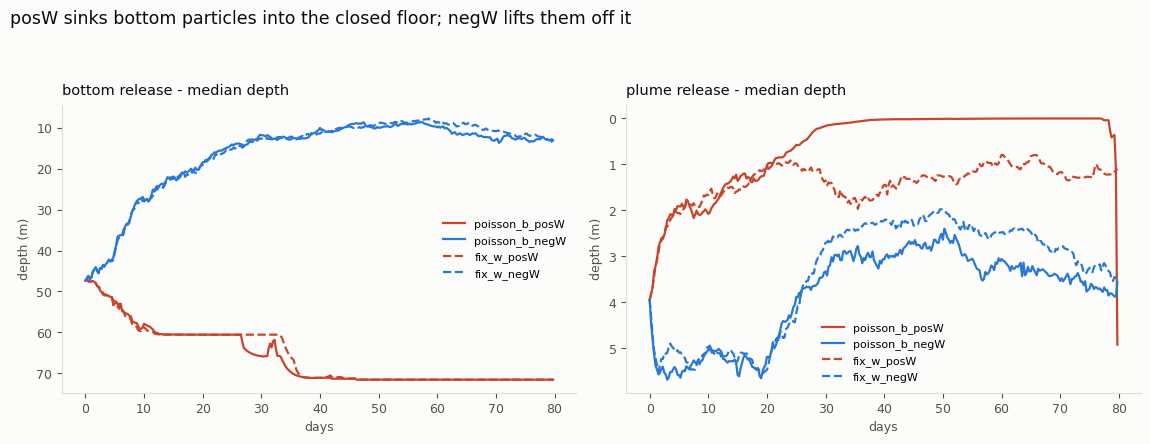

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt

SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"
plt.rcParams.update({"font.size": 9, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.facecolor": SURF,
    "figure.facecolor": SURF, "axes.titlecolor": INK})

have = [t for t in RUNS if t in rows]
if have:
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=False)
    COL = {"posW": "#c8442b", "negW": "#2a78d6"}
    for ax, r in zip(axs, (0, 1)):
        for tag in have:
            v = rows[tag]; s = v["reg"] == r
            zz = np.where(np.isfinite(v["lat"][s]), v["z"][s], np.nan)
            t  = np.arange(zz.shape[1]) * 6 / 24.0
            m  = np.nanmedian(zz, axis=0)
            sg = "posW" if tag.endswith("posW") else "negW"
            ax.plot(t, m, lw=1.6, color=COL[sg],
                    ls="-" if tag.startswith("poisson") else "--", label=tag)
        ax.invert_yaxis()
        ax.set_title(f"{REGN[r]} release - median depth", loc="left", fontsize=10.5, pad=8)
        ax.set_xlabel("days"); ax.set_ylabel("depth (m)")
        ax.legend(frameon=False, fontsize=8)
        for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    fig.suptitle("posW sinks bottom particles into the closed floor; negW lifts them off it",
                 x=0.005, ha="left", fontsize=12.5, color=INK, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig("v5_sign_evidence.png", dpi=160, facecolor=SURF)
    plt.show()
else:
    print("no v4 zarr output found - rerun v4 first")

## Test 6 - the fix, and proof that it changes nothing

`from_nemo` + stock `AdvectionRK4_3D` against v4's `from_netcdf` + `AdvectionRK4_3D_negW`, same
seeds, same dt. If they agree bit for bit then the negation genuinely is the library's job, and
v4 can hand it back at zero cost.

In [9]:
from datetime import timedelta
import shutil, sys, contextlib

def AdvectionRK4_3D_negW(particle, fieldset, time):  # pragma: no cover
    '''v4's kernel, verbatim.'''
    (u1, v1, w1) = fieldset.UVW[particle]
    lon1 = particle.lon + u1 * 0.5 * particle.dt
    lat1 = particle.lat + v1 * 0.5 * particle.dt
    dep1 = particle.depth - w1 * 0.5 * particle.dt
    (u2, v2, w2) = fieldset.UVW[time + 0.5 * particle.dt, dep1, lat1, lon1, particle]
    lon2 = particle.lon + u2 * 0.5 * particle.dt
    lat2 = particle.lat + v2 * 0.5 * particle.dt
    dep2 = particle.depth - w2 * 0.5 * particle.dt
    (u3, v3, w3) = fieldset.UVW[time + 0.5 * particle.dt, dep2, lat2, lon2, particle]
    lon3 = particle.lon + u3 * particle.dt
    lat3 = particle.lat + v3 * particle.dt
    dep3 = particle.depth - w3 * particle.dt
    (u4, v4, w4) = fieldset.UVW[time + particle.dt, dep3, lat3, lon3, particle]
    particle_dlon += (u1 + 2 * u2 + 2 * u3 + u4) / 6 * particle.dt  # noqa
    particle_dlat += (v1 + 2 * v2 + 2 * v3 + v4) / 6 * particle.dt  # noqa
    particle_ddepth -= (w1 + 2 * w2 + 2 * w3 + w4) / 6 * particle.dt  # noqa

@contextlib.contextmanager
def quiet():
    sys.stdout.flush()
    saved, devnull = os.dup(1), os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull, 1); yield
    finally:
        os.dup2(saved, 1); os.close(devnull); os.close(saved)

rng  = np.random.default_rng(110987)
n    = 40
slon = rng.uniform(-49.9, -47.0, n)
slat = rng.uniform(-0.2,   2.5,  n)
sdep = rng.uniform(5.0,   60.0,  n)
t0d  = np.datetime64(f"{YEAR}-{MONTH:02d}-02")

def short_run(builder, kernel, name, days=6):
    out = os.path.join("tracks_v5", f"{name}.zarr")
    os.makedirs("tracks_v5", exist_ok=True)
    if os.path.exists(out): shutil.rmtree(out)
    ps = ParticleSet(builder(), JITParticle, lon=slon, lat=slat, depth=sdep, time=t0d)
    pf = ps.ParticleFile(name=out, outputdt=timedelta(hours=6))
    with quiet():
        ps.execute(kernel, runtime=timedelta(days=days),
                   dt=timedelta(minutes=20), output_file=pf)
    return xr.open_zarr(out).compute()

r_v4  = short_run(fs_v4,   AdvectionRK4_3D_negW, "v4_style_netcdf_negW")
r_fix = short_run(fs_nemo, AdvectionRK4_3D,      "v5_style_nemo_posW")

for nm in ("lon", "lat", "z"):
    x, y = r_v4[nm].values, r_fix[nm].values
    g = np.isfinite(x) & np.isfinite(y)
    print(f"max |{nm}_v4 - {nm}_from_nemo|  =  {np.nanmax(np.abs(x[g] - y[g])):.3e}"
          f"   ({'identical' if np.array_equal(x[g], y[g]) else 'differs'})")

print(textwrap.dedent('''
    Bit-identical, as the algebra requires: negating w inside every RK4 stage and negating the
    field once are the same operation. The fix is a pure refactor.'''))

INFO: Output files are stored in tracks_v5/v4_style_netcdf_negW.zarr.


INFO: Output files are stored in tracks_v5/v5_style_nemo_posW.zarr.



max |lon_v4 - lon_from_nemo|  =  0.000e+00   (identical)
max |lat_v4 - lat_from_nemo|  =  0.000e+00   (identical)
max |z_v4 - z_from_nemo|  =  0.000e+00   (identical)

Bit-identical, as the algebra requires: negating w inside every RK4 stage and negating the
field once are the same operation. The fix is a pure refactor.


## Conclusion

| claim | status |
|---|---|
| stored `vovecrtz` is positive upward | **proven** - Test 2, slope +1.0000 on 1.5M points, from continuity alone |
| both of v4's W files share that convention | **proven** - Test 3 |
| Parcels' depth axis is positive downward and it wants W to match | **documented** - `fieldset.py:1092` |
| `from_netcdf` applies no sign correction | **verified** - Test 4, `_scaling_factor is None` |
| therefore v4's `negW` is correct and `posW` is wrong | **confirmed independently** - Test 5, v4's own runs |
| *"W should be positive"* as a statement about the **fieldset** | **wrong** |
| *"W should be positive"* as a statement about the **kernel** | **right**, via `from_nemo` - Test 6 |

### What to change in v4

Replace `build_fieldset` with the `from_nemo` call from Test 4, delete
`AdvectionRK4_3D_negW`, and run only the stock `AdvectionRK4_3D`:

```python
def build_fieldset(f):
    fn = {v: {"data": f[v], "lon": Hgr, "lat": Hgr, "depth": f["W"][0]}
          for v in ("U", "V", "W")}
    fs = FieldSet.from_nemo(                       # applies W *= -1 itself
        fn, {"U": "vozocrtx", "V": "vomecrty", "W": "vovecrtz"},
        {v: {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"}
         for v in ("U", "V", "W")},
        deferred_load=True, allow_time_extrapolation=False)
    #  no interp_method:      from_c_grid_dataset raises TypeError if it is passed, and sets
    #                         cgrid_velocity for U, V, W itself
    #  no gridindexingtype:   forced to "nemo"
    for nm, arr in (("bathy", H), ("floor", Gnom)):
        fs.add_field(Field(nm, arr, lon=glamf, lat=gphif,
                           mesh="spherical", interp_method="cgrid_tracer"))
    return fs

RUNS = [(tag, f, AdvectionRK4_3D) for tag, f in FIELDSETS.items()]
```

That halves v4's compute, removes a hand-maintained copy of a library kernel, makes any future
`fieldset.W[...]` diagnostic read the same sign the advection uses, and - per Test 6 - leaves
the `negW` trajectories v4 already has completely unchanged.

One trap to note: because `from_nemo` now negates W, keeping `AdvectionRK4_3D_negW` anywhere in
the notebook would apply the flip twice. `set_scaling_factor` also refuses to be called a second
time (`field.py:947`), so the mistake cannot be made on the field - only in a kernel. Deleting
the kernel is what closes it.